**Program**: 5c_PISA_CategoricalMathModels_v2 <br>
**Group**: Spring 2025, Data Mining, Final Project, Group 11<br>
**Group Members**: Sean Fitzgerald, Nick Mobus, Vanessa Thorsten<br>
**Description**: This program reads in the analysis dataset dfCOG.csv, which includes country level data from the PISA student testing, SES, student questionnaire, as well as GDP and percent GDP spent on education by country.<br>

This analysis focuses on our seventh question, which was, "How does food availability affect student performance generally?" Random forest and K-nearest neighbor models are performed with an outcome of binned math proficiency. Specifically, we are interested in the following three proficiency categories: Score Level 1: Did not meet minimum proficiency, Score Level 5-6: Top Performers, Score Level 2-4: Met minimum proficiency, but not top performers. This is the primary predictor of interest. We will also include other variables that are known to have a relationship with the math score from our visualizations. These variables include SES quartile, GDP (middle-income, high-income) and the 6 regions.<br>

**Program History/Modifications**:<br>
04/10/2025    Initial Version<br>
04/17/2025    Added models for continuous SES and GDP instead of categorical.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import kneighbors_graph
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# class weighted neural network on an imbalanced classification dataset
from sklearn.datasets import make_classification
#import tensorflow as tf
#from tensorflow import keras
#from keras.layers import Dense
#from keras.models import Sequential

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay

from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

In [2]:
dfpisa = pd.read_csv("dfCOG.csv")
dfpisa=dfpisa.drop(['Unnamed: 0'], axis = 1)
dfpisa.head()

,CNTRYID,country,math_all_mean,math_10th_mean,math_25th_mean,math_50th_mean,math_75th_mean,math_90th_mean,math_diff_90_10,math_diff_90_10_se,...,high_life_satisfaction,high_life_satisfaction_cat,high_growth_mindset_cat,low_growth_mindset_cat,high_grit,high_grit_cat,low_grit,low_grit_cat,high_love_learn,high_love_learn_cat
0,100,Bulgaria,417,298,346,411,483,549,251,6.8,...,0.5293,>=50%,High,Medium,0.6108,>=60%,0.2247,20-30%,0.7403,<75%
1,116,Cambodia,336,244,288,336,383,428,184,4.6,...,0.5879,>=50%,NaN,NaN,NaN,NaN,NaN,NaN,0.8379,>=75%
2,124,Canada,497,375,430,496,562,619,244,2.7,...,NaN,NaN,Medium,Medium,0.6175,>=60%,0.1324,10-19%,0.7126,<75%
3,152,Chile,412,315,358,409,464,514,198,3.3,...,0.3990,<50%,High,Medium,0.7616,>=60%,0.0819,0-9%,0.7966,>=75%
4,158,Chinese Taipei,547,393,470,554,628,687,294,6.8,...,0.4272,<50%,Medium,Medium,0.7018,>=60%,0.0503,0-9%,0.6278,<75%


In [3]:
dfpisa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Columns: 128 entries, CNTRYID to high_love_learn_cat
dtypes: float64(83), int64(31), object(14)
memory usage: 81.1+ KB


In [4]:
dfpisa["country"].value_counts()

,count
country,
Bulgaria,1
Cambodia,1
Canada,1
Chile,1
Chinese Taipei,1
...,...
United States,1
Uruguay,1
Uzbekistan,1


#### **Question 7. How does food availability affect student performance generally?**


In [5]:
#Subset to variables of interest
dfpisa_Q7 = pd.DataFrame(dfpisa[["country", "ST258Q01JA_1.0_proportion", "ST258Q01JA_2.0_proportion",
                                 "ST258Q01JA_3.0_proportion", "ST258Q01JA_4.0_proportion",
                                 "ST258Q01JA_5.0_proportion",
                                 "math_all_mean", "read_all_mean", "scie_all_mean",
                                 "country_gdp", "country_gdp_cat", "ses_all_mean",
                                 "Geo_Region", "high_life_satisfaction",
                                 "ST307Q02JA_1.0_proportion", "ST303Q04JA_1.0_proportion",
                                 "ed_percent_gdp"]])

In [6]:
dfpisa_Q7[['ses_all_mean', 'country_gdp']].describe()

,ses_all_mean,country_gdp
count,80.000000,80.000000
mean,-0.357625,40573.125979
std,0.583400,26573.328769
min,-2.010000,5663.121600
25%,-0.735000,18705.666750
50%,-0.245000,37492.644500
75%,0.087500,56166.665500
max,0.520000,131864.100000


In [7]:
#Add variable for Binned Math Proficiency
#Math = <420.07, greater than or equal to 420.07
mathcat_bins = [0, 420.07, 482.38, 600]
#Variable labels
mathcat_labels = ['1_Below minimum proficiency', '2_Met minimum proficiency', '3_Above minimum proficiency']
#Create variables
dfpisa_Q7['math_proficiency_cat'] = pd.cut(dfpisa_Q7['math_all_mean'], bins=mathcat_bins, labels=mathcat_labels, right=True)

In [8]:
#Add variable for Binned Math Proficiency
#Math = <420.07, greater than or equal to 420.07
mathcat_bins = [0, 420.07, 482.38, 600]
#Variable labels
mathcat_labels = [1, 2, 3]
#Create variables
dfpisa_Q7['math_prof_ncat'] = pd.cut(dfpisa_Q7['math_all_mean'], bins=mathcat_bins, labels=mathcat_labels, right=True)

In [9]:
#Check variable creation - math proficiency cat
print(dfpisa_Q7[['math_all_mean','math_prof_ncat']])

    math_all_mean math_prof_ncat
0             417              1
1             336              1
2             497              3
3             412              1
4             547              3
..            ...            ...
76            465              2
77            409              1
78            364              1
79            441              2
80            442              2

[81 rows x 2 columns]


In [10]:
#Check distribution
dfpisa_Q7['math_proficiency_cat'].value_counts()

,count
math_proficiency_cat,
1_Below minimum proficiency,34
2_Met minimum proficiency,26
3_Above minimum proficiency,21


In [11]:
#Add variable for SES Quartiles
dfpisa_Q7['ses_all_cat'] = pd.cut(dfpisa_Q7['ses_all_mean'], bins=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], right=True)

In [12]:
#Check distribution
dfpisa_Q7['ses_all_cat'].value_counts()

,count
ses_all_cat,
Q4,33
Q3,27
Q2,15
Q1,5


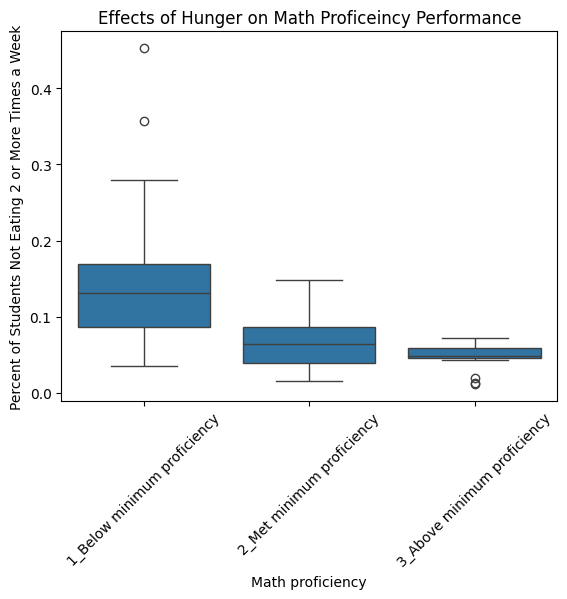

In [13]:
dfpisa_Q7['ST258_3_to_5'] = dfpisa_Q7['ST258Q01JA_3.0_proportion']+dfpisa_Q7['ST258Q01JA_4.0_proportion']+dfpisa_Q7['ST258Q01JA_5.0_proportion']
dfpisa_Q7['not_eat_cat'] = pd.cut(dfpisa_Q7['ST258_3_to_5'], bins=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], right=True)

sns.boxplot(data=dfpisa_Q7,y='ST258_3_to_5', x='math_proficiency_cat')
plt.ylabel('Percent of Students Not Eating 2 or More Times a Week')
plt.xlabel('Math proficiency')
plt.xticks (rotation = 45) #rotate label
plt.title("Effects of Hunger on Math Proficeincy Performance")
plt.show()

In [14]:
### Handle missing values, outliers, and irrelevant features.

### Check for missing values
print("\nMissing Values:")
print(dfpisa_Q7.isnull().sum())


Missing Values:
country                       0
ST258Q01JA_1.0_proportion    15
ST258Q01JA_2.0_proportion    15
ST258Q01JA_3.0_proportion    15
ST258Q01JA_4.0_proportion    15
ST258Q01JA_5.0_proportion    15
math_all_mean                 0
read_all_mean                 0
scie_all_mean                 0
country_gdp                   1
country_gdp_cat               2
ses_all_mean                  1
Geo_Region                    0
high_life_satisfaction        8
ST307Q02JA_1.0_proportion     9
ST303Q04JA_1.0_proportion    10
ed_percent_gdp                0
math_proficiency_cat          0
math_prof_ncat                0
ses_all_cat                   1
ST258_3_to_5                 15
not_eat_cat                  15
dtype: int64


In [15]:
#Replace missing values with the median for variables that are not the primary question(i.e. not missing food security)
dfpisa_Q7.fillna({'country_gdp': dfpisa_Q7['country_gdp'].median()}, inplace=True)
dfpisa_Q7.fillna({'high_life_satisfaction': dfpisa_Q7['high_life_satisfaction'].median()}, inplace=True)
dfpisa_Q7.fillna({'ST307Q02JA_1.0_proportion': dfpisa_Q7['ST307Q02JA_1.0_proportion'].median()}, inplace=True)
dfpisa_Q7.fillna({'ST303Q04JA_1.0_proportion': dfpisa_Q7['ST303Q04JA_1.0_proportion'].median()}, inplace=True)
dfpisa_Q7.fillna({'ses_all_mean': dfpisa_Q7['ses_all_mean'].median()}, inplace=True)

In [16]:
df = dfpisa_Q7[dfpisa_Q7['not_eat_cat'].notna()]

In [17]:
### Confirm no missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
country                      0
ST258Q01JA_1.0_proportion    0
ST258Q01JA_2.0_proportion    0
ST258Q01JA_3.0_proportion    0
ST258Q01JA_4.0_proportion    0
ST258Q01JA_5.0_proportion    0
math_all_mean                0
read_all_mean                0
scie_all_mean                0
country_gdp                  0
country_gdp_cat              2
ses_all_mean                 0
Geo_Region                   0
high_life_satisfaction       0
ST307Q02JA_1.0_proportion    0
ST303Q04JA_1.0_proportion    0
ed_percent_gdp               0
math_proficiency_cat         0
math_prof_ncat               0
ses_all_cat                  0
ST258_3_to_5                 0
not_eat_cat                  0
dtype: int64


In [18]:
df[['not_eat_cat','ses_all_cat','country_gdp_cat', 'Geo_Region']].value_counts()

not_eat_cat  ses_all_cat  country_gdp_cat               Geo_Region    
Q1           Q4           >12,695 High Income           Western Europe    12
             Q3           >12,695 High Income           Eastern Europe     6
                                                        Asia               5
             Q2           >12,695 High Income           South America      5
             Q4           >12,695 High Income           Eastern Europe     4
Q2           Q3           >12,695 High Income           Eastern Europe     3
Q1           Q4           >12,695 High Income           North America      2
                                                        Asia               2
Q2           Q2           <=12,695 Upper-Middle Income  Middle East        2
Q1           Q1           >12,695 High Income           Asia               1
             Q2           >12,695 High Income           North America      1
                                                        Middle East        1
             Q3           >12,695 High Income           Western Europe     1
                                                        South America      1
             Q2           <=12,695 Upper-Middle Income  Asia               1
             Q1           <=12,695 Upper-Middle Income  North America      1
Q2           Q1           <=12,695 Upper-Middle Income  North America      1
Q1           Q3           >12,695 High Income           North America      1
Q2           Q2           >12,695 High Income           Asia               1
             Q1           <=12,695 Upper-Middle Income  Western Europe     1
             Q2           >12,695 High Income           North America      1
             Q3           <=12,695 Upper-Middle Income  Asia               1
                                                        Western Europe     1
             Q2           >12,695 High Income           Eastern Europe     1
             Q3           >12,695 High Income           Asia               1
                                                        Western Europe     1
             Q4           >12,695 High Income           Asia               1
                                                        Middle East        1
Q3           Q2           <=12,695 Upper-Middle Income  Asia               1
             Q3           >12,695 High Income           Middle East        1
Q4           Q1           <=12,695 Upper-Middle Income  Asia               1
             Q3           <=12,695 Upper-Middle Income  North America      1
Name: count, dtype: int64

In [19]:
#Scale mean ses and country gdp
scaler = StandardScaler()
df['ses_all_mean'] = scaler.fit_transform(df[['ses_all_mean']])
df['country_gdp'] = scaler.fit_transform(df[['country_gdp']])

df[['ses_all_mean', 'country_gdp']].describe()

<ipython-input-19-c173576dfac5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ses_all_mean'] = scaler.fit_transform(df[['ses_all_mean']])
<ipython-input-19-c173576dfac5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country_gdp'] = scaler.fit_transform(df[['country_gdp']])


,ses_all_mean,country_gdp
count,6.600000e+01,6.600000e+01
mean,1.328903e-16,5.080111e-16
std,1.007663e+00,1.007663e+00
min,-2.660260e+00,-1.195102e+00
25%,-6.575593e-01,-7.938538e-01
50%,1.596105e-01,-2.261692e-01
75%,8.158867e-01,5.507723e-01
max,1.556844e+00,3.396969e+00


In [20]:
#Separate the data into x and y datasets
x=df.drop(['math_prof_ncat', 'ST258Q01JA_1.0_proportion', 'ST258Q01JA_2.0_proportion', 'ST258Q01JA_3.0_proportion',
 'ST258Q01JA_4.0_proportion', 'ST258Q01JA_5.0_proportion', 'math_all_mean',
 'read_all_mean', 'scie_all_mean', 'math_proficiency_cat', 'country',
 'not_eat_cat','ses_all_cat','country_gdp_cat', 'Geo_Region'
           ], axis=1).copy()
y=df['math_prof_ncat'].copy()

In [21]:
# Create training and test sets from the data corrected for class imbalance with the over sampling method
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.30, stratify=y, random_state=123)

print(df.shape)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

print(x_train.describe())
print(y_train.describe())
print(x_test.describe())
print(y_test.describe())

(66, 22)
(46, 7)
(46,)
(20, 7)
(20,)
       country_gdp  ses_all_mean  high_life_satisfaction  \
count    46.000000     46.000000               46.000000   
mean     -0.047776      0.052103                0.501567   
std       0.984758      0.877737                0.110348   
min      -1.195102     -1.813452                0.269700   
25%      -0.755783     -0.509368                0.427775   
50%      -0.238991      0.210419                0.499400   
75%       0.362768      0.743908                0.575525   
max       3.396969      1.302801                0.748300   

       ST307Q02JA_1.0_proportion  ST303Q04JA_1.0_proportion  ed_percent_gdp  \
count                  46.000000                  46.000000       46.000000   
mean                    0.068085                   0.038237        4.362303   
std                     0.032045                   0.019080        0.965042   
min                     0.018800                   0.011300        2.187878   
25%                     0.0

In [22]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 0 to 80
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_gdp                66 non-null     float64
 1   ses_all_mean               66 non-null     float64
 2   high_life_satisfaction     66 non-null     float64
 3   ST307Q02JA_1.0_proportion  66 non-null     float64
 4   ST303Q04JA_1.0_proportion  66 non-null     float64
 5   ed_percent_gdp             66 non-null     float64
 6   ST258_3_to_5               66 non-null     float64
dtypes: float64(7)
memory usage: 4.1 KB


## Random Forest

In [23]:
# Initialize the classifiers
rf=RandomForestClassifier(class_weight="balanced", criterion='gini', max_depth=8, n_estimators =300,
                          min_samples_split=20, min_samples_leaf=10, random_state=123)
#fit to the training set
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=300, random_state=123)

### Assess classification random forest model on test data

In [24]:
# Predict the test set probabilities of one versus rest of the classes
y_pred_proba_rf = rf.predict_proba(x_test)
roc_auc_value_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class="ovr")
roc_auc_value_rf

np.float64(0.8048773448773449)

In [25]:
# Predict the test set probabilities of one versus one of the classes
roc_auc_value_rf_ovo = roc_auc_score(y_test, y_pred_proba_rf, multi_class="ovo")
roc_auc_value_rf_ovo

np.float64(0.7722222222222223)

In [26]:
print(f"y_score:\n{y_pred_proba_rf[0:2,:]}")
print()
print(f"y_score.ravel():\n{y_pred_proba_rf[0:2,:].ravel()}")

y_score:
[[0.7169307  0.20136539 0.08170391]
 [0.6754451  0.26389983 0.06065507]]

y_score.ravel():
[0.7169307  0.20136539 0.08170391 0.6754451  0.26389983 0.06065507]


In [27]:
label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape  # (n_samples, n_classes)

(20, 3)

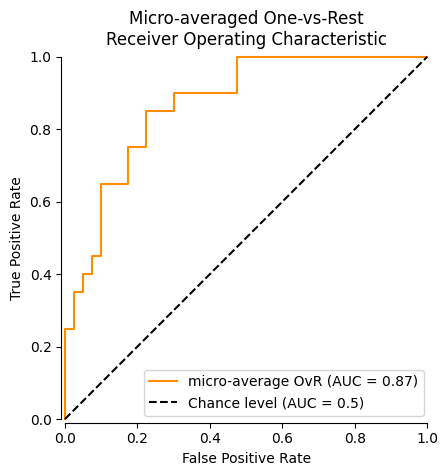

In [28]:
## ROC curve
display = RocCurveDisplay.from_predictions(
    y_onehot_test.ravel(),
    y_pred_proba_rf.ravel(),
    name="micro-average OvR",
    color="darkorange",
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic",
)

In [29]:
#For trees, a record is associated with a leaf, and the class with the highest probability
#  is assigned as the predicted class.
y_pred_prob_rf = rf.predict(x_test)
test_accuracy_rf = accuracy_score(y_test, y_pred_prob_rf)
test_accuracy_rf

0.7

In [30]:
# [true negatives,  false positives
#  false negatives, true positives]

# Sensitivity = true positives / (true positives + false negatives)
# Specificity = true negatives / (true negatives + false positives)

# Precision = true positives / (true positives + false positives)
#  Also know as Positive Predictive Value

print(confusion_matrix(y_test, y_pred_prob_rf))
print("")
print(y_test.value_counts())

[[8 1 0]
 [2 1 3]
 [0 0 5]]

math_prof_ncat
1    9
2    6
3    5
Name: count, dtype: int64


In [31]:
#Positive Predictive Value (focusing on positive event) = 'precision' within the '1' row.
#Sensitivity (focusing on positive event) = 'recall' within the '1' row.

#f1-score = 2*(precision*recall)/(precision + recall)  #harmonic mean of precision and recall.

#support is the number of occurrences of each class in y_test

print(classification_report(y_test, y_pred_prob_rf))

              precision    recall  f1-score   support

           1       0.80      0.89      0.84         9
           2       0.50      0.17      0.25         6
           3       0.62      1.00      0.77         5

    accuracy                           0.70        20
   macro avg       0.64      0.69      0.62        20
weighted avg       0.67      0.70      0.65        20



### Set the random forest's hyperparameter grid

In [32]:
# Define params_rf
params_rf = {'n_estimators': [300, 400, 500], 'max_depth': [2,3,5,8], 'class_weight' : ["balanced"],
             'random_state': [123]}

### Search for the optimal random forest¶

In [33]:
# initialize rf
grid_rf = GridSearchCV(estimator=rf,
                       param_grid=params_rf,
                       scoring='roc_auc',
                       cv=10,
                       n_jobs=-1)

### Evaluate the optimal random forest

In [34]:
# Fit the rf
grid_rf.fit(x_train, y_train)

# Extract the best estimator
best_model_rf = grid_rf.best_estimator_

# Look at the best model hyperparameters
print (best_model_rf.get_params())

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False}


In [35]:
# Predict the test set probabilities of the positive class
y_pred_proba_orf = best_model_rf.predict_proba(x_test)
test_roc_auc_orf = roc_auc_score(y_test, y_pred_proba_orf, multi_class="ovr")
# Print test_roc_auc
print('Test set ROC AUC score: {:.3f}'.format(test_roc_auc_orf))

Test set ROC AUC score: 0.805


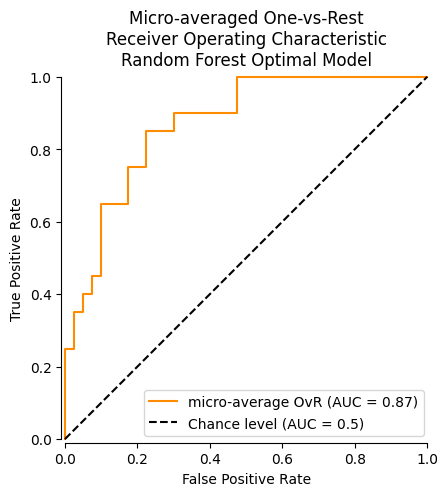

In [132]:
## ROC curve
display = RocCurveDisplay.from_predictions(
    y_onehot_test.ravel(),
    y_pred_proba_orf.ravel(),
    name="micro-average OvR",
    color="darkorange",
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic\nRandom Forest Optimal Model",
)

### Assess predicted classes on optimal random forest model test data

In [37]:
#For trees, a record is associated with a leaf, and the class with the highest probability
#  is assigned as the predicted class.
y_pred_prob_orf = best_model_rf.predict(x_test)
test_accuracy_orf = accuracy_score(y_test, y_pred_prob_orf)
test_accuracy_orf

0.7

In [38]:
# [true negatives,  false positives
#  false negatives, true positives]

# Sensitivity = true positives / (true positives + false negatives)
# Specificity = true negatives / (true negatives + false positives)

# Precision = true positives / (true positives + false positives)
#  Also know as Positive Predictive Value

print(confusion_matrix(y_test, y_pred_prob_orf))
print("")
print(y_test.value_counts())

[[8 1 0]
 [2 1 3]
 [0 0 5]]

math_prof_ncat
1    9
2    6
3    5
Name: count, dtype: int64


In [39]:
#Positive Predictive Value (focusing on positive event) = 'precision' within the '1' row.
#Sensitivity (focusing on positive event) = 'recall' within the '1' row.

#f1-score = 2*(precision*recall)/(precision + recall)  #harmonic mean of precision and recall.

#support is the number of occurrences of each class in y_test

print(classification_report(y_test, y_pred_prob_orf))

              precision    recall  f1-score   support

           1       0.80      0.89      0.84         9
           2       0.50      0.17      0.25         6
           3       0.62      1.00      0.77         5

    accuracy                           0.70        20
   macro avg       0.64      0.69      0.62        20
weighted avg       0.67      0.70      0.65        20



### Partial dependence plots for optimal random forest model
Look for the directionality of the results.

Partial dependence plots show the dependence between the target function and a set of ‘target’ features, marginalizing over the values of all other features (the complement features).

Partial dependency plots: Not meeting minimal math proficiency. Comparison group for food security is the low food insecurity group.


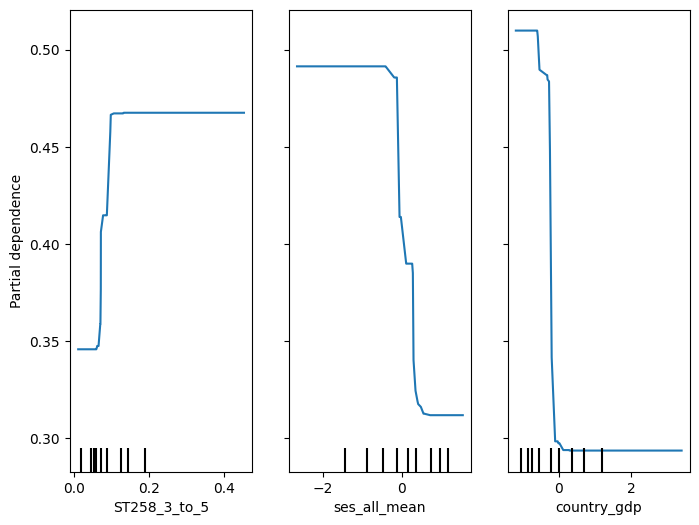

In [41]:
print("Partial dependency plots: Not meeting minimal math proficiency. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean',
'country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_rf, x, features_to_plot, ax=ax, target=1)
plt.show()

Partial dependency plots: Meeting minimal math proficiency but not higher. Comparison group for food security is the low food insecurity group.


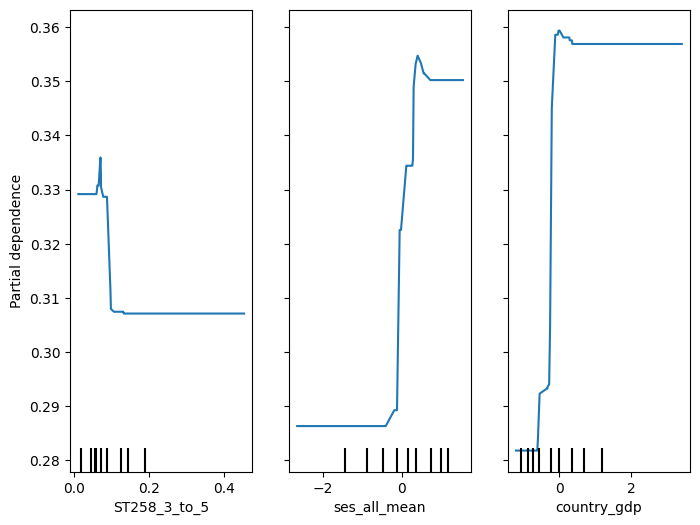

In [43]:
print("Partial dependency plots: Meeting minimal math proficiency but not higher. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean',
'country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_rf, x, features_to_plot, ax=ax, target=2)
plt.show()

Partial dependency plots: Above minimal math proficiency. Comparison group for food security is the low food insecurity group.


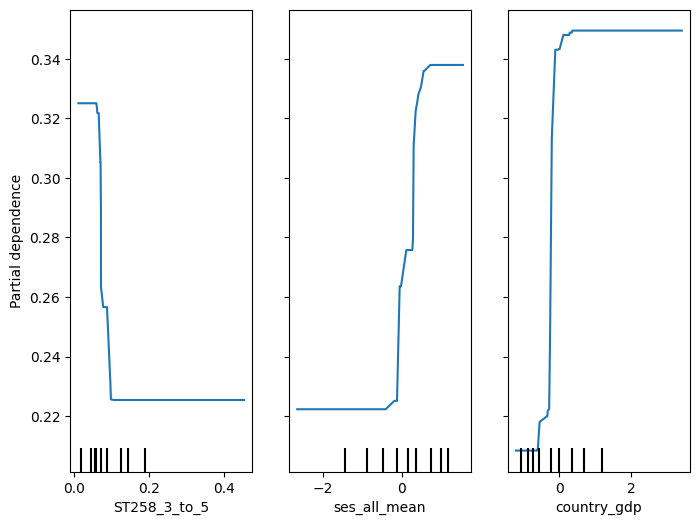

In [45]:
print("Partial dependency plots: Above minimal math proficiency. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean',
'country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_rf, x, features_to_plot, ax=ax, target=3)
plt.show()

#### Feature importance Optimal Random Forest Model

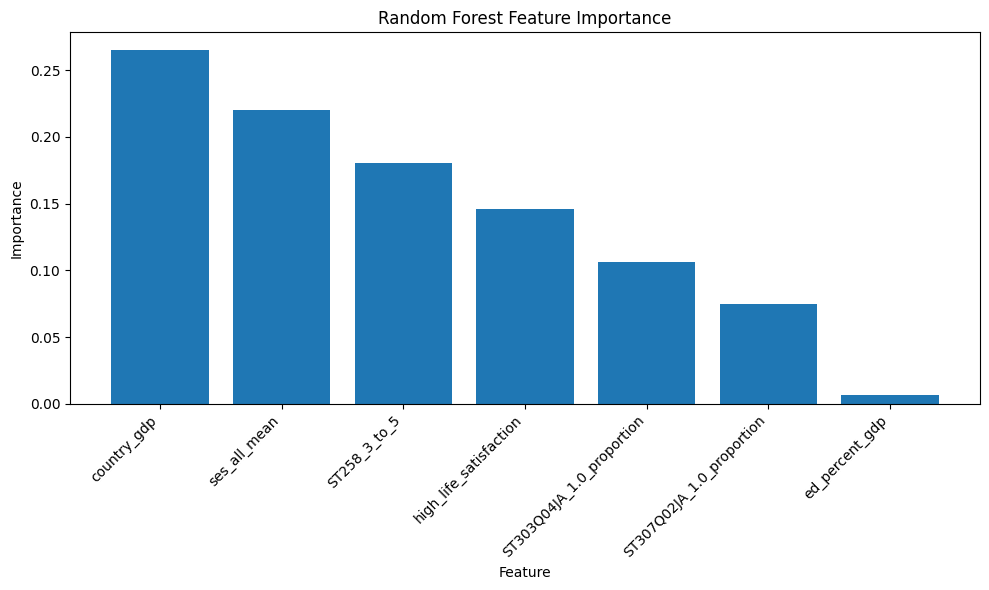

In [46]:
# Extract feature importances
result_rf = best_model_rf.feature_importances_

# Create a DataFrame for feature importance
feature_importance_rf = pd.DataFrame({'Feature': x.columns, 'Importance': result_rf})
feature_importance_rf = feature_importance_rf.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_rf['Feature'], feature_importance_rf['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### K nearest neighbors

In [107]:
# KNN model did not work with all of the parameters.
# It had a number of fits fail. Reduce the number of parameters
x_knn_train = x_train.filter(['ST258_3_to_5', 'ses_all_mean','country_gdp'])
x_knn_test = x_test.filter(['ST258_3_to_5', 'ses_all_mean','country_gdp'])

x_knn_train.info()
x_knn_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 17 to 9
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ST258_3_to_5  46 non-null     float64
 1   ses_all_mean  46 non-null     float64
 2   country_gdp   46 non-null     float64
dtypes: float64(3)
memory usage: 1.4 KB
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 47 to 72
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ST258_3_to_5  20 non-null     float64
 1   ses_all_mean  20 non-null     float64
 2   country_gdp   20 non-null     float64
dtypes: float64(3)
memory usage: 640.0 bytes


In [108]:
# Instantiate the classifiers
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model on the training data
knn.fit(x_knn_train, y_train)
y_pred_proba_kn = knn.predict_proba(x_knn_test)
roc_auc_value_kn = roc_auc_score(y_test, y_pred_proba_kn, multi_class="ovr")
roc_auc_value_kn

np.float64(0.7501875901875902)

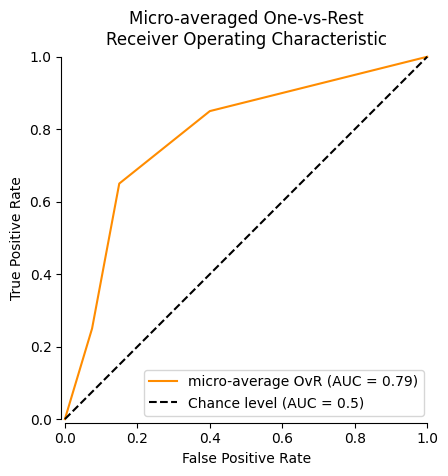

In [131]:
## ROC curve
display = RocCurveDisplay.from_predictions(
    y_onehot_test.ravel(),
    y_pred_proba_kn.ravel(),
    name="micro-average OvR",
    color="darkorange",
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic",
)

### Assess predicted classes on test data

In [110]:
y_pred_prob_kn = knn.predict(x_knn_test)
test_accuracy_kn = accuracy_score(y_test, y_pred_prob_kn)
test_accuracy_kn

0.65

In [111]:
#Positive Predictive Value (focusing on positive event) = 'precision' within the '1' row.
#Sensitivity (focusing on positive event) = 'recall' within the '1' row.

#f1-score = 2*(precision*recall)/(precision + recall)  #harmonic mean of precision and recall.

#support is the number of occurrences of each class in y_test

print(classification_report(y_test, y_pred_prob_kn))

              precision    recall  f1-score   support

           1       0.73      0.89      0.80         9
           2       0.67      0.33      0.44         6
           3       0.50      0.60      0.55         5

    accuracy                           0.65        20
   macro avg       0.63      0.61      0.60        20
weighted avg       0.65      0.65      0.63        20



### Set the nearest neighbor's hyperparameter grid

In [112]:
# Define params_kn
params_kn = {'n_neighbors': [2, 3, 4, 5], 'metric': ['euclidean', 'manhattan', 'minkowski']}

### Search for the optimal nearest neighbor model¶

In [113]:
# Instantiate kn
grid_kn = GridSearchCV(estimator=knn,
                       param_grid=params_kn,
                       scoring='roc_auc',
                       cv=10,
                       n_jobs=-1)

### Evaluate the optimal nearest neighbor model

In [114]:
# Fit the kn
grid_kn.fit(x_knn_train, y_train)

# Extract the best estimator
best_model_kn = grid_kn.best_estimator_

# Look at the best model hyperparameters
print (best_model_kn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 2, 'p': 2, 'weights': 'uniform'}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [115]:
# Predict the test set probabilities of the positive class
y_pred_proba_okn = best_model_kn.predict_proba(x_knn_test)
test_roc_auc_okn = roc_auc_score(y_test, y_pred_proba_okn, multi_class="ovr")
# Print test_roc_auc
print('Test set ROC AUC score: {:.3f}'.format(test_roc_auc_okn))

Test set ROC AUC score: 0.762


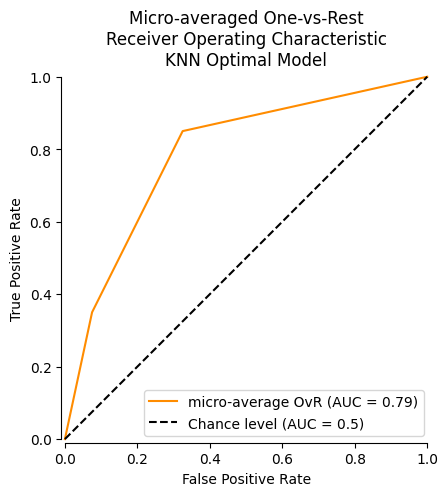

In [136]:
## ROC curve
display = RocCurveDisplay.from_predictions(
    y_onehot_test.ravel(),
    y_pred_proba_okn.ravel(),
    name="micro-average OvR",
    color="darkorange",
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic\nKNN Optimal Model",
)

### Assess predicted classes on optimal k-nearest neighbors model test data

In [117]:
# class with the highest probability
#  is assigned as the predicted class.
y_pred_prob_okn = best_model_kn.predict(x_knn_test)
test_accuracy_okn = accuracy_score(y_test, y_pred_prob_okn)
test_accuracy_okn

0.65

In [118]:
# [true negatives,  false positives
#  false negatives, true positives]

# Sensitivity = true positives / (true positives + false negatives)
# Specificity = true negatives / (true negatives + false positives)

# Precision = true positives / (true positives + false positives)
#  Also know as Positive Predictive Value

print(confusion_matrix(y_test, y_pred_prob_okn))
print("")
print(y_test.value_counts())

[[8 0 1]
 [2 4 0]
 [0 4 1]]

math_prof_ncat
1    9
2    6
3    5
Name: count, dtype: int64


In [119]:
#Positive Predictive Value (focusing on positive event) = 'precision' within the '1' row.
#Sensitivity (focusing on positive event) = 'recall' within the '1' row.

#f1-score = 2*(precision*recall)/(precision + recall)  #harmonic mean of precision and recall.

#support is the number of occurrences of each class in y_test

print(classification_report(y_test, y_pred_prob_okn))

              precision    recall  f1-score   support

           1       0.80      0.89      0.84         9
           2       0.50      0.67      0.57         6
           3       0.50      0.20      0.29         5

    accuracy                           0.65        20
   macro avg       0.60      0.59      0.57        20
weighted avg       0.64      0.65      0.62        20



### Partial dependence plots for optimal KNN model
Look for the directionality of the results.

Partial dependence plots show the dependence between the target function and a set of ‘target’ features, marginalizing over the values of all other features (the complement features).

Partial dependency plots: Not meeting minimal math proficiency. Comparison group for food security is the low food insecurity group.


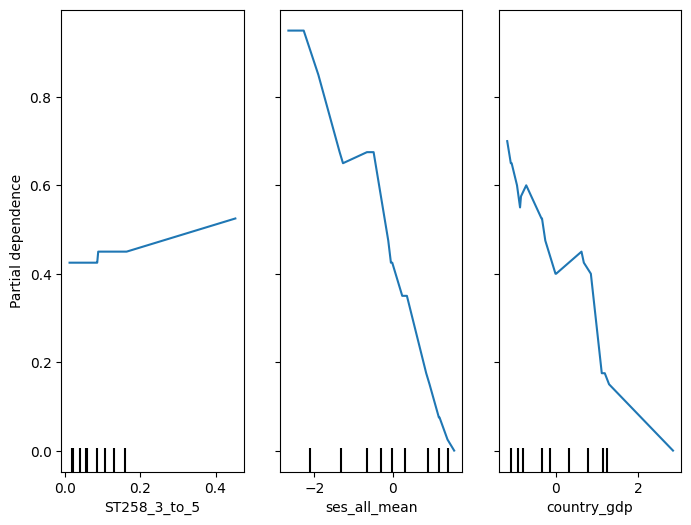

In [120]:
print("Partial dependency plots: Not meeting minimal math proficiency. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean',
'country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_kn, x_knn_test, features_to_plot, ax=ax, target=1)
plt.show()

Partial dependency plots: Meeting minimal math proficiency but not higher. Comparison group for food security is the low food insecurity group.


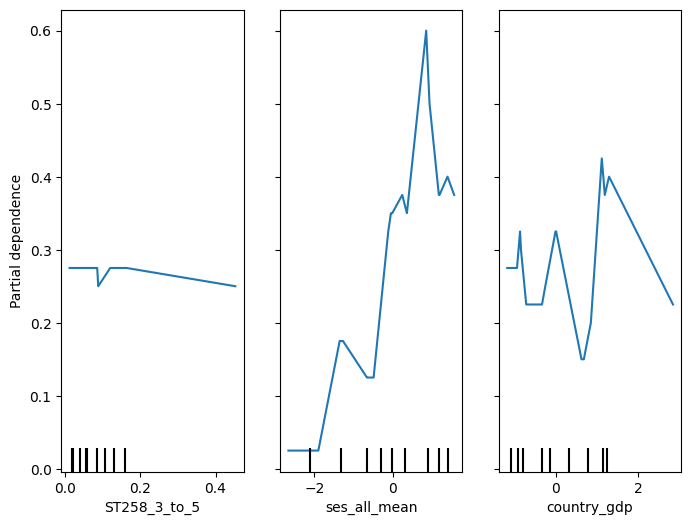

In [121]:
print("Partial dependency plots: Meeting minimal math proficiency but not higher. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean','country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_kn, x_knn_test, features_to_plot, ax=ax, target=2)
plt.show()

Partial dependency plots: Above minimal math proficiency. Comparison group for food security is the low food insecurity group.


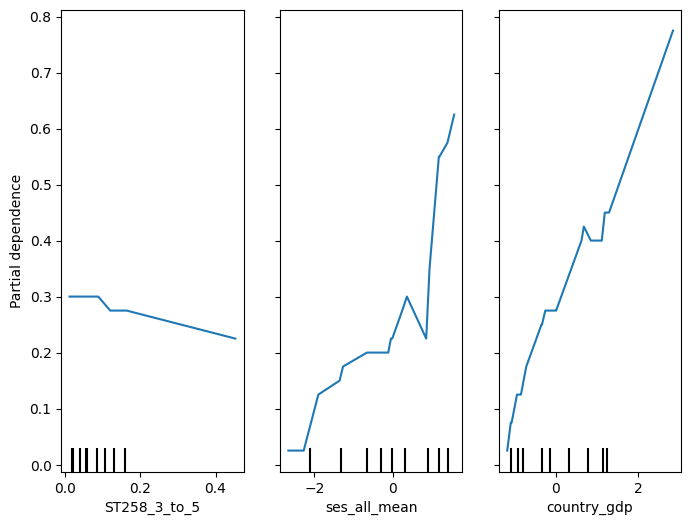

In [122]:
print("Partial dependency plots: Above minimal math proficiency. Comparison group for food security is the low food insecurity group.")
features_to_plot = ['ST258_3_to_5', 'ses_all_mean',
'country_gdp'] # Feature indices or names
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(best_model_kn, x_knn_test, features_to_plot, ax=ax, target=3)
plt.show()

### Feature Importance (using permutation importance) for KNN Model

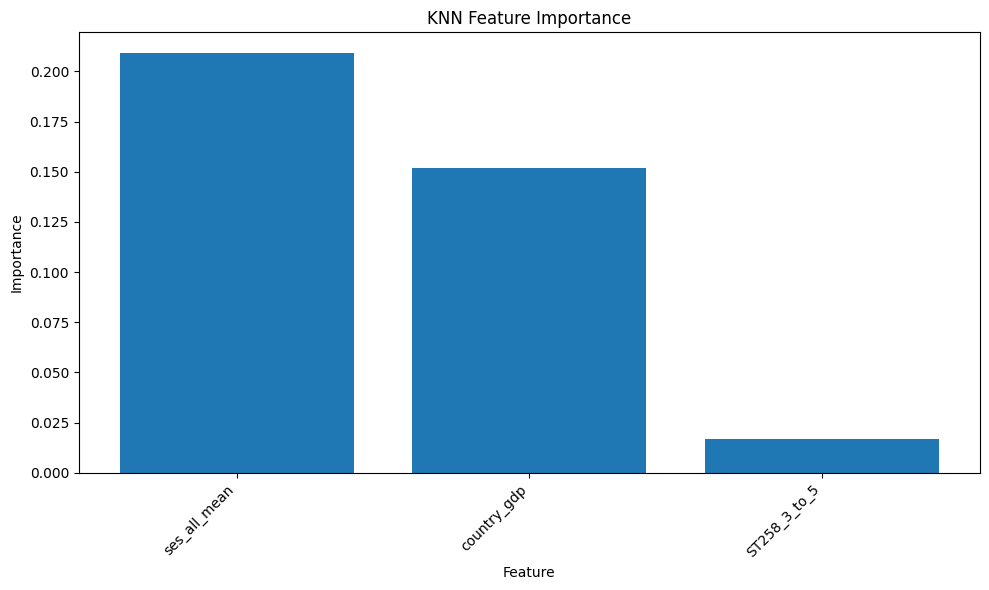

In [124]:
# Calculate permutation importance
result_kn = permutation_importance(best_model_kn, x_knn_test, y_test, n_repeats=100, random_state=42)

# Create a DataFrame for feature importance
feature_importance_kn = pd.DataFrame({'Feature': x_knn_test.columns, 'Importance': result_kn.importances_mean})
feature_importance_kn = feature_importance_kn.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_kn['Feature'], feature_importance_kn['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('KNN Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Create summary table

In [133]:
def create_model_df(y_true, y_pred, model_name, data_config):
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Convert to DataFrame
    df_cm = pd.DataFrame(cm, columns=['Pred: < min prof', 'Pred: min prof', 'Pred: > min prof'])

    df_cm['row_num'] = range(1, len(df_cm) + 1)

    # Generate classification report as a dictionary
    cl_dict = classification_report(y_true, y_pred, output_dict=True)

    # Convert to DataFrame and transpose
    df_cl = pd.DataFrame(cl_dict).T

    df_cl['Model'] = model_name
    df_cl['Data'] = data_config
    df_cl['row_num'] = range(1, len(df_cl) + 1)

    del df_cl['support']

    df_cmcl = pd.merge(df_cm, df_cl, how='left', on = 'row_num')

    return (df_cmcl)

In [134]:
df_cmcl_rf       = create_model_df(y_test, y_pred_prob_rf, 'Random Forest', 'Does food availability affect math scores?')
df_cmcl_kn       = create_model_df(y_test, y_pred_prob_kn, 'KNN', 'Does food availability affect math scores?')

# stack the DataFrames
compare_df = pd.concat([df_cmcl_rf, df_cmcl_kn], ignore_index=True, axis=0)

# Add column with the actual values
col         = 'row_num'
conditions  = [ compare_df[col] == 1, compare_df[col] == 2, compare_df[col] == 3]
choices     = [ '< min proficiency', 'min proficiency', '> min proficiency' ]
default_value = " "

compare_df["Actual"] = np.select(conditions, choices, default=default_value)

# Delete row number
del compare_df['row_num']

# reorder columns
compare_df = compare_df[['Data','Model', 'Actual', 'Pred: < min prof', 'Pred: min prof', 'Pred: > min prof', 'precision', 'recall', 'f1-score']]

In [135]:
pd.set_option('display.expand_frame_repr', False)
print(compare_df)

                                         Data          Model             Actual  Pred: < min prof  Pred: min prof  Pred: > min prof  precision    recall  f1-score
0  Does food availability affect math scores?  Random Forest  < min proficiency                 8               1                 0   0.800000  0.888889  0.842105
1  Does food availability affect math scores?  Random Forest    min proficiency                 2               1                 3   0.500000  0.166667  0.250000
2  Does food availability affect math scores?  Random Forest  > min proficiency                 0               0                 5   0.625000  1.000000  0.769231
3  Does food availability affect math scores?            KNN  < min proficiency                 8               0                 1   0.727273  0.888889  0.800000
4  Does food availability affect math scores?            KNN    min proficiency                 2               2                 2   0.666667  0.333333  0.444444
5  Does food availabil